# DBA5101 Project 1 - Estimation of Demand

## Imports

In [120]:
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import statsmodels.api as sm

## Data Processing

In [121]:
DATA_PATH = Path("../data/Data-GP1-revised-final.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,num_seats_total,mean_net_ticket_price,Dept_Date,Purchase_Date,Train_Number_All,isNormCabin,isReturn,isOneway,Customer_Cat
0,1,188.663422,10/9/19,10/10/18,A,1,0,0,A
1,1,358.428869,5/27/19,6/6/18,B,0,1,0,A
2,1,356.372684,5/31/20,6/17/19,B,0,1,0,A
3,1,396.370505,12/10/19,12/27/18,C,0,1,0,A
4,1,364.264552,5/31/20,6/19/19,B,0,1,0,A


In [122]:
df.isna().sum()

num_seats_total          0
mean_net_ticket_price    0
Dept_Date                0
Purchase_Date            0
Train_Number_All         0
isNormCabin              0
isReturn                 0
isOneway                 0
Customer_Cat             0
dtype: int64

In [123]:
# Convert to datetime
df["Dept_Date"] = pd.to_datetime(df["Dept_Date"], format="%m/%d/%y")
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"], format="%m/%d/%y")

# Find total amount paid for aggregation
df["total_amt_paid"] = df["num_seats_total"] * df["mean_net_ticket_price"]
df = df.drop(columns=["mean_net_ticket_price"])

# Reorder columns
df = df[[
    "Dept_Date",
    "Purchase_Date",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat",
    "total_amt_paid",
    "num_seats_total"
]]

In [124]:
# We aggregate by ("Dept_Date", "Purchase_Date", "Train_Number_All", "isNormCabin", "isReturn", "isOneway", "Customer_Cat")
# Each unique tuple is taken to be:
# - Same customer type
# - Same train ride
# - Purchased at the same time
# This corresponds to one data point

group_cols = [
    "Dept_Date",
    "Purchase_Date",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat"
]

agg_groups_and_sizes = df.groupby(group_cols).size().reset_index(name="group_size")
agg_groups_and_sizes["group_size"].value_counts()

group_size
1    202866
2      3390
3        17
Name: count, dtype: int64

In [125]:
agg_groups_and_sizes.shape

(206273, 8)

In [126]:
# Do the aggregation between rows of the same group to get (price, quantity) for each group
agg_df = df.groupby(group_cols).agg(
    total_amt_paid=("total_amt_paid", "sum"),
    quantity=("num_seats_total", "sum"),
).reset_index()

agg_df["price"] = agg_df["total_amt_paid"] / agg_df["quantity"]
agg_df.head()


,Dept_Date,Purchase_Date,Train_Number_All,isNormCabin,isReturn,isOneway,Customer_Cat,total_amt_paid,quantity,price
0,2018-06-01,2018-06-01,A,0,0,0,A,418.084961,1,418.084961
1,2018-06-01,2018-06-01,C,0,0,1,B,1224.703645,2,612.351822
2,2018-06-01,2018-06-01,F,0,0,1,B,406.927566,1,406.927566
3,2018-06-01,2018-06-01,G,0,0,1,A,563.725911,1,563.725911
4,2018-06-01,2018-06-01,I,0,0,1,A,580.439887,1,580.439887


In [127]:
# Add derived features
agg_df["days_in_advance"] = (agg_df["Dept_Date"] - agg_df["Purchase_Date"]).dt.days
agg_df["dept_month_of_year"] = agg_df["Dept_Date"].dt.month
agg_df["dept_day_of_week"] = agg_df["Dept_Date"].dt.day_name()
agg_df["ln_price"] = np.log(agg_df["price"])
agg_df["ln_quantity"] = np.log(agg_df["quantity"])

agg_df = agg_df.drop(columns=["Dept_Date", "Purchase_Date", "total_amt_paid"])

agg_df = agg_df[[
    "quantity",
    "ln_quantity",
    "price",
    "ln_price",
    "Train_Number_All",
    "isNormCabin",
    "isReturn",
    "isOneway",
    "Customer_Cat",
    "days_in_advance",
    "dept_month_of_year",
    "dept_day_of_week"
]]

agg_df = agg_df.rename(columns={
    "Train_Number_All": "train_num",
    "isNormCabin": "is_norm_cabin",
    "isReturn": "is_return",
    "isOneway": "is_oneway",
    "Customer_Cat": "customer_cat"
})

In [128]:
agg_df.head()

,quantity,ln_quantity,price,ln_price,train_num,is_norm_cabin,is_return,is_oneway,customer_cat,days_in_advance,dept_month_of_year,dept_day_of_week
0,1,0.000000,418.084961,6.035685,A,0,0,0,A,0,6,Friday
1,2,0.693147,612.351822,6.417307,C,0,0,1,B,0,6,Friday
2,1,0.000000,406.927566,6.008635,F,0,0,1,B,0,6,Friday
3,1,0.000000,563.725911,6.334568,G,0,0,1,A,0,6,Friday
4,1,0.000000,580.439887,6.363786,I,0,0,1,A,0,6,Friday


In [129]:
agg_df.shape

(206273, 12)

## Distributions of Variables

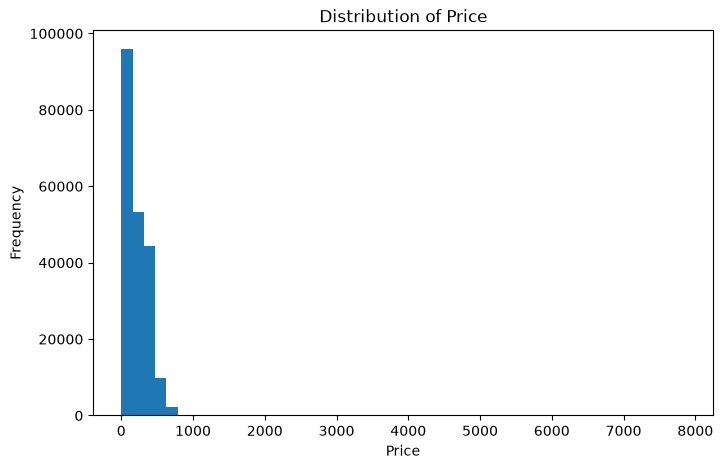

In [130]:
# Distribution of Price (P)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")
plt.show()

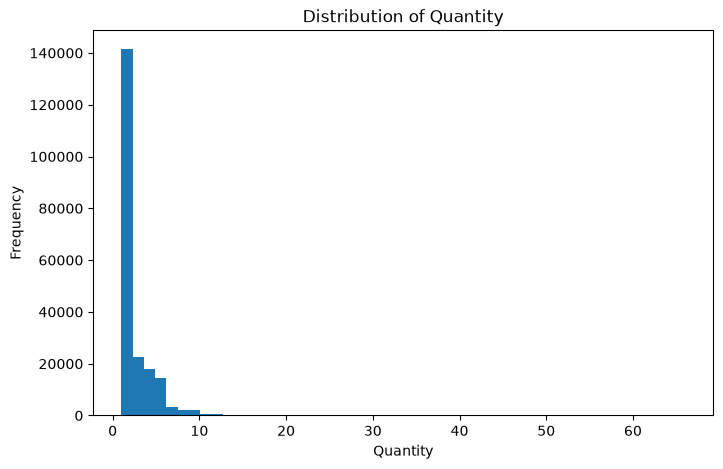

In [131]:
# Distribution of Quantity (Q)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

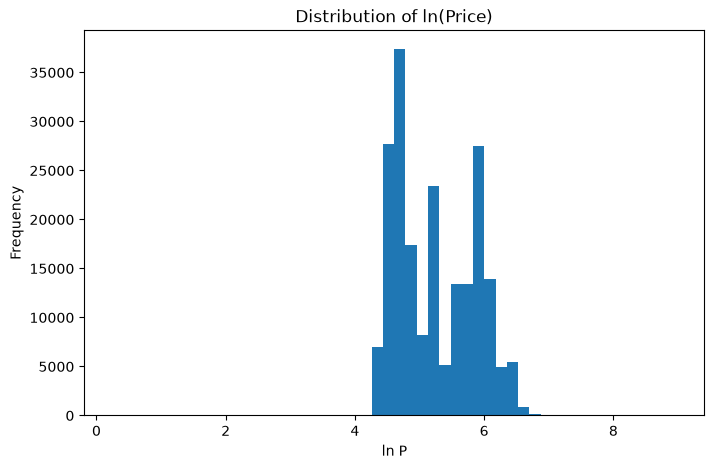

In [132]:
# Distribution of Log of Price (ln P)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["ln_price"], bins=50)
plt.xlabel("ln P")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Price)")
plt.show()

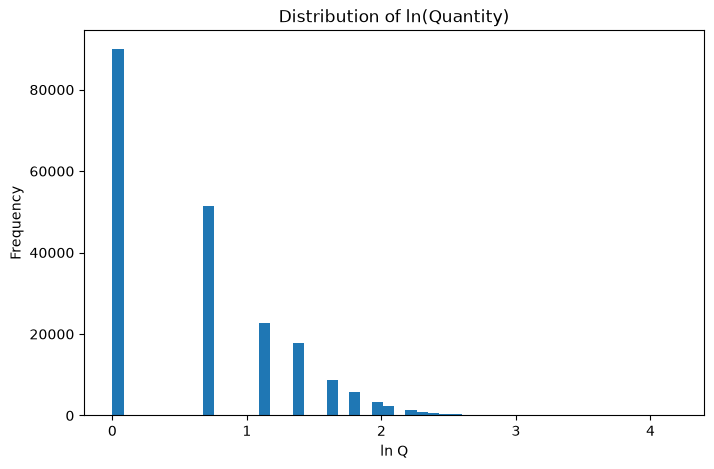

In [133]:
# Distribution of Log of Quantity (ln Q)
plt.figure(figsize=(8, 5))
plt.hist(agg_df["ln_quantity"], bins=50)
plt.xlabel("ln Q")
plt.ylabel("Frequency")
plt.title("Distribution of ln(Quantity)")
plt.show()

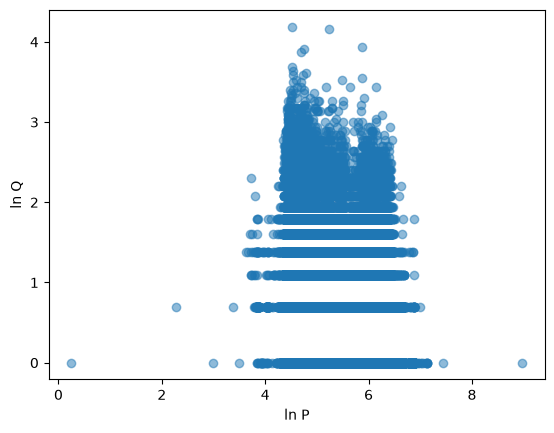

In [134]:
# Scatter plot of ln Q against ln P
plt.scatter(agg_df["ln_price"], agg_df["ln_quantity"], alpha=0.5)
plt.xlabel("ln P")
plt.ylabel("ln Q")
plt.show()

## OLS

In [135]:
# Dependent variable
y = agg_df["ln_quantity"]

# Independent variables
X = agg_df[[
    "ln_price",
    "train_num",
    "is_norm_cabin",
    "is_return",
    "is_oneway",
    "customer_cat",
    "days_in_advance",
    "dept_month_of_year",
    "dept_day_of_week"
]]

# Convert categorical variables to dummy variables
X = pd.get_dummies(
    X,
    columns=[
        "train_num",
        "customer_cat",
        "dept_month_of_year",
        "dept_day_of_week"
    ],
    drop_first=True
)

# Add intercept
X = sm.add_constant(X)

In [136]:
X

,const,ln_price,is_norm_cabin,is_return,is_oneway,days_in_advance,train_num_B,train_num_C,train_num_D,train_num_E,...,dept_month_of_year_9,dept_month_of_year_10,dept_month_of_year_11,dept_month_of_year_12,dept_day_of_week_Monday,dept_day_of_week_Saturday,dept_day_of_week_Sunday,dept_day_of_week_Thursday,dept_day_of_week_Tuesday,dept_day_of_week_Wednesday
0,1.0,6.035685,0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.0,6.417307,0,0,1,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.0,6.008635,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.0,6.334568,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,6.363786,0,0,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206268,1.0,5.231469,1,1,1,354,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
206269,1.0,4.614339,1,0,0,349,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
206270,1.0,5.843385,0,0,0,350,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
206271,1.0,5.179893,1,1,0,354,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [137]:
ols_model = sm.OLS(y, X).fit()

In [138]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     868.7
Date:               Wed, 09 Sept 2026   Prob (F-statistic):               0.00
Time:                        20:56:01   Log-Likelihood:            -1.9351e+05
No. Observations:              206273   AIC:                         3.871e+05
Df Residuals:                  206235   BIC:                         3.875e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.3617      0.025     55.511      0.000       1.314       1.410
ln_price                      -0.1970      0.004    -51.406      0.000      -0.205      -0.189
is_norm_cabin                 -0.0714      0.004    -17.514      0.000      -0.079      -0.063
is_return                      0.0134      0.004      3.042      0.002       0.005       0.022
is_oneway                     -0.0828      0.004    -19.450      0.000      -0.091      -0.074
days_in_advance                0.0005   2.69e-05     17.315      0.000       0.000       0.001
train_num_B                    0.1800      0.008     23.442      0.000       0.165       0.195
train_num_C                    0.0944      0.009     11.096      0.000       0.078       0.111
train_num_D                    0.0101      0.009      1.179      0.238      -0.007       0.027
train_num_E                    0.2051      0.007     29.765      0.000       0.192       0.219
train_num_F                    0.1460      0.007     19.947      0.000       0.132       0.160
train_num_G                    0.1362      0.008     17.418      0.000       0.121       0.152
train_num_H                    0.1483      0.007     20.414      0.000       0.134       0.163
train_num_I                    0.0590      0.008      7.263      0.000       0.043       0.075
train_num_J                    0.0186      0.008      2.359      0.018       0.003       0.034
train_num_K                   -0.0595      0.010     -5.958      0.000      -0.079      -0.040
train_num_L                    0.0043      0.010      0.431      0.666      -0.015       0.024
train_num_M                   -0.1041      0.009    -12.168      0.000      -0.121      -0.087
train_num_N                   -0.1875      0.014    -13.157      0.000      -0.215      -0.160
train_num_O                   -0.5981      0.618     -0.967      0.333      -1.810       0.614
customer_cat_B                 0.2618      0.004     67.276      0.000       0.254       0.269
dept_month_of_year_2          -0.0328      0.007     -4.468      0.000      -0.047      -0.018
dept_month_of_year_3           0.0830      0.007     12.720      0.000       0.070       0.096
dept_month_of_year_4           0.0369      0.007      5.219      0.000       0.023       0.051
dept_month_of_year_5          -0.0068      0.007     -1.010      0.312      -0.020       0.006
dept_month_of_year_6           0.1001      0.006     15.529      0.000       0.088       0.113
dept_month_of_year_7          -0.0587      0.007     -8.844      0.000      -0.072      -0.046
dept_month_of_year_8          -0.0313      0.007     -4.511      0.000      -0.045      -0.018
dept_month_of_year_9          -0.0567      0.007     -8.381      0.000      -0.070      -0.043
dept_month_of_year_10         -0.0394      

## 2SLS

In [139]:
tsls_model = IV2SLS.from_formula(
    """
    ln_quantity ~ 1
        + is_norm_cabin
        + is_return
        + is_oneway
        + C(customer_cat)
        + C(train_num)
        + C(dept_month_of_year)
        + C(dept_day_of_week)
        + [ln_price ~ days_in_advance]
    """,
    data=agg_df
).fit()

In [140]:
tsls_model.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:            ln_quantity   R-squared:                      0.1276
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1274
No. Observations:              206273   F-statistic:                 2.267e+05
Date:               Wed, Sept 09 2026   P-value (F-stat)                0.0000
Time:                        20:56:04   Distribution:                 chi2(36)
Cov. Estimator:                robust                                         
                                                                              
                                        Parameter Estimates                                         
====================================================================================================
                                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------------
Intercept                            2.3212     0.0518     44.770     0.0000      2.2196      2.4228
is_norm_cabin                       -0.1712     0.0070    -24.499     0.0000     -0.1849     -0.1575
is_return                            0.0068     0.0044     1.5613     0.1185     -0.0017      0.0154
is_oneway                           -0.0639     0.0043    -14.891     0.0000     -0.0724     -0.0555
C(customer_cat)[T.B]                 0.2256     0.0043     52.013     0.0000      0.2171      0.2342
C(train_num)[T.B]                    0.1877     0.0076     24.729     0.0000      0.1729      0.2026
C(train_num)[T.C]                    0.1334     0.0086     15.503     0.0000      0.1165      0.1503
C(train_num)[T.D]                    0.0209     0.0082     2.5410     0.0111      0.0048      0.0370
C(train_num)[T.E]                    0.1988     0.0070     28.493     0.0000      0.1851      0.2125
C(train_num)[T.F]                    0.1479     0.0073     20.316     0.0000      0.1336      0.1621
C(train_num)[T.G]                    0.1404     0.0077     18.251     0.0000      0.1254      0.1555
C(train_num)[T.H]                    0.1447     0.0072     20.022     0.0000      0.1305      0.1588
C(train_num)[T.I]                    0.0695     0.0078     8.8617     0.0000      0.0541      0.0849
C(train_num)[T.J]                    0.0155     0.0076     2.0308     0.0423      0.0005      0.0304
C(train_num)[T.K]                   -0.0483     0.0093    -5.2185     0.0000     -0.0664     -0.0302
C(train_num)[T.L]                    0.0322     0.0095     3.4039     0.0007      0.0137      0.0508
C(train_num)[T.M]                   -0.1091     0.0080    -13.586     0.0000     -0.1249     -0.0934
C(train_num)[T.N]                   -0.1610     0.0104    -15.539     0.0000     -0.1813     -0.1407
C(train_num)[T.O]                   -0.5176     0.0110    -47.228     0.0000     -0.5390     -0.4961
C(dept_month_of_year)[T.2]          -0.0325     0.0072    -4.5240     0.0000     -0.0466     -0.0184
C(dept_month_of_year)[T.3]           0.0699     0.0066     10.564     0.0000      0.0569      0.0829
C(dept_month_of_year)[T.4]           0.0348     0.0070     4.9969     0.0000      0.0211      0.0484
C(dept_month_of_year)[T.5]          -0.0190     0.0065    -2.9070     0.0036     -0.0318     -0.0062
C(dept_month_of_year)[T.6]           0.1019     0.0065     15.744     0.0000      0.0892      0.1145
C(dept_month_of_year)[T.7]          -0.0742     0.0064    -11.676     0.0000     -0.0867     -0.0618
C(dept_month_of_year)[T.8]          -0.0339     0.0069    -4.9443     0.0000     -0.0474     -0.0205
C(dept_month_of_year)[T.9]          -0.0742     0.0066    -11.205     0.0000     -0.0872     -0.0612
C(dept_month_of_year)[T.10]         -0.0499     0.0064    -7.7935     0.0000     -0.0625     -0.0374
C(d

In [141]:
tsls_model.first_stage

,ln_price
R-squared,0.6595
Partial R-squared,0.1727
Shea's R-squared,0.1727
Partial F-statistic,2.718e+04
P-value (Partial F-stat),0.0000
Partial F-stat Distn,chi2(1)
==================================,===========
Intercept,6.0092
,(1247.4)
is_norm_cabin,-0.6254


In [142]:
tsls_model.wu_hausman()

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 299.8090
P-value: 0.0000
Distributed: F(1,206235)
WaldTestStatistic, id: 0x26e9ada2ed0